# Блок 5. Итоговое тестирование

## Описание блока:
В данном блоке будут обучены лучшие ML модели с подобранными гиперпараметрами для каждой группы датасетов. Подробное текстовое описания получившегося результата будет в  [Открыть тетрадку "Part 0"](Part%200.%20Research%20results.ipynb)

In [1]:
# импорт основных библиотек блока
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor

import sys
import os

# Добавляем родительскую директорию в sys.path
sys.path.append(os.path.abspath(".."))

from all_functions.datasets_load import load_all_datasets
from all_functions.datasets_transfom import *
from all_functions.func_for_ml import * 


In [2]:
# фиксация сида на будущее
RANDOM_STATE = 654321

In [3]:
# загрузка датасетов
crypt_Ethereum, crypt_BTC, futures_Brent_LCOK5, \
futures_WTI_CLJ5, share_metal_jiangxi_copper, \
share_metal_baoshan_iron, share_oil_petrochina_hk, \
share_oil_equinor_oslo, spot_preciouse_metal_AG, spot_preciouse_metal_AU = load_all_datasets()

In [4]:
# трансформация датасетов
crypt_Ethereum = transform_data(crypt_Ethereum)
crypt_BTC = transform_data(crypt_BTC)

futures_WTI_CLJ5 = transform_data(futures_WTI_CLJ5)
futures_Brent_LCOK5 = transform_data(futures_Brent_LCOK5)

share_metal_jiangxi_copper  = transform_data(share_metal_jiangxi_copper)
share_metal_baoshan_iron  = transform_data(share_metal_baoshan_iron)

share_oil_petrochina_hk  = transform_data(share_oil_petrochina_hk)
share_oil_equinor_oslo  = transform_data(share_oil_equinor_oslo)

spot_preciouse_metal_AU  = transform_data(spot_preciouse_metal_AU)
spot_preciouse_metal_AG = transform_data(spot_preciouse_metal_AG)

## Тестирование на тестовой выборке

In [5]:
def best_model_GradientBoostingRegressor(data, name, best_params):
    '''Функция по построению лучшей модели c использованием GradientBoostingRegressor'''
    
    line_length = 150
    print('-' * line_length)
    print(f'Тестирование датасета: {name}'.center(line_length))
    print('-' * line_length)

   # --- Разделение данных ---
    train_raw, valid_raw, test_raw = split_data(data)
    tail_len = 30

    train = upgrade_dataset(train_raw)
    valid = upgrade_dataset(valid_raw)
    test_with_tail = pd.concat([valid_raw.tail(tail_len), test_raw])
    test_with_tail = upgrade_dataset(test_with_tail)
    test = test_with_tail.loc[test_raw.index]

    X_train, y_train = return_x_y(train)
    X_test, y_test = return_x_y(test)
    
    # 4. Обучение модели
    model = GradientBoostingRegressor(**best_params)
    model.fit(X_train, y_train)
    
    # 5. Предсказание
    y_pred = model.predict(X_test)
    
    # 6. Оценка RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"RMSE на валидации: {rmse:.4f}")
    
    # 7. График
    plt.figure(figsize=(10, 5))
    plt.plot(y_test.index, y_test, label="Факт", color='blue')
    plt.plot(y_test.index, y_pred, label="Прогноз", color='orange')
    plt.title("прогноз и факт")
    plt.xlabel("Дата")
    plt.ylabel("Цена")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
def best_model_LGBM(data, name, best_params):
    '''Функция по построению лучшей модели c использованием GradientBoostingRegressor'''
    
    line_length = 150
    print('-' * line_length)
    print(f'Тестирование датасета: {name}'.center(line_length))
    print('-' * line_length)

   # --- Разделение данных ---
    train_raw, valid_raw, test_raw = split_data(data)
    tail_len = 30

    train = upgrade_dataset(train_raw)
    valid = upgrade_dataset(valid_raw)
    test_with_tail = pd.concat([valid_raw.tail(tail_len), test_raw])
    test_with_tail = upgrade_dataset(test_with_tail)
    test = test_with_tail.loc[test_raw.index]

    X_train, y_train = return_x_y(train)
    X_test, y_test = return_x_y(test)
    
    # 4. Обучение модели
    model = LGBMRegressor(**best_params, verbose = -1)
    model.fit(X_train, y_train)
    
    # 5. Предсказание
    y_pred = model.predict(X_test)
    
    # 6. Оценка RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"RMSE на валидации: {rmse:.4f}")
    
    # 7. График
    plt.figure(figsize=(10, 5))
    plt.plot(y_test.index, y_test, label="Факт", color='blue')
    plt.plot(y_test.index, y_pred, label="Прогноз", color='orange')
    plt.title("прогноз и факт")
    plt.xlabel("Дата")
    plt.ylabel("Цена")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Криптовалюты

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                        Тестирование датасета: crypt_Ethereum                                                         
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 129.0017


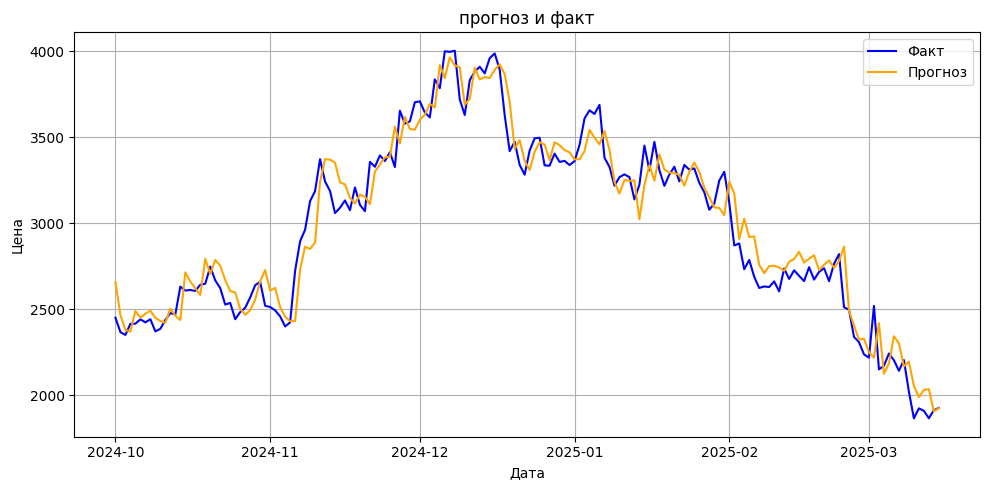

In [7]:
best_model_GradientBoostingRegressor(crypt_Ethereum, 'crypt_Ethereum', {'n_estimators': 239, 'learning_rate': 0.04063717639143676, 'max_depth': 4, 'subsample': 0.6303381907682958, 'min_samples_split': 7, 'min_samples_leaf': 5})

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                           Тестирование датасета: crypt_BTC                                                           
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 27743.8896


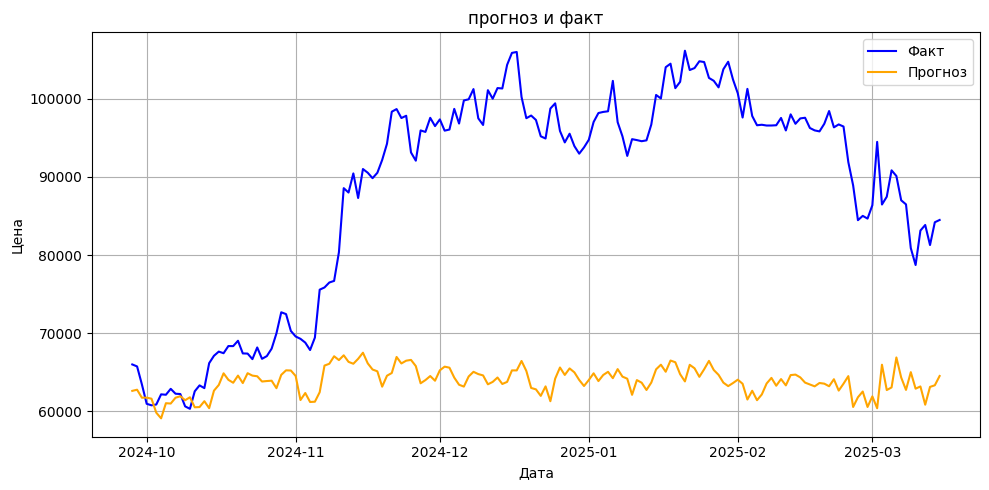

In [8]:
best_model_GradientBoostingRegressor(crypt_BTC, 'crypt_BTC', {'n_estimators': 271, 'learning_rate': 0.11575814816810856, 'max_depth': 3, 'subsample': 0.5834474426183737, 'min_samples_split': 8, 'min_samples_leaf': 4})

### Нефтеные фьючерсы

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                       Тестирование датасета: futures_WTI_CLJ5                                                        
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 1.5906


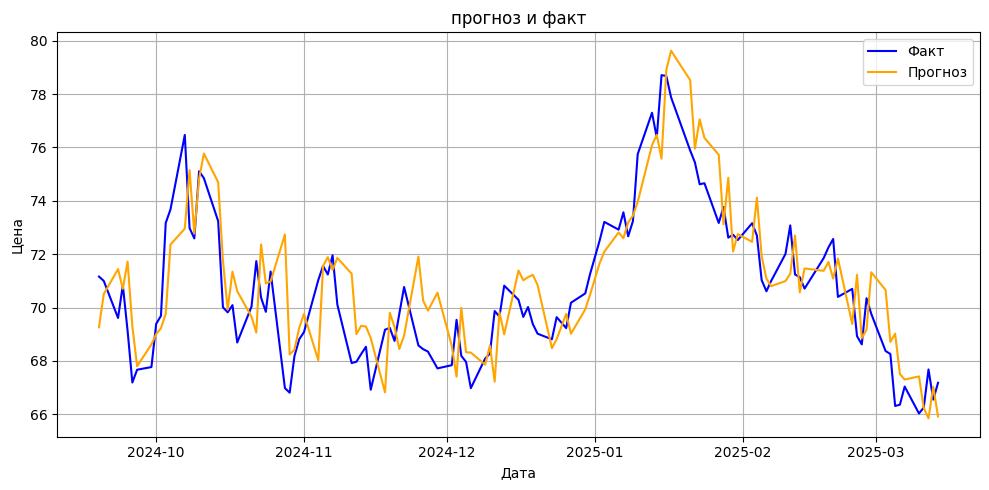

In [9]:
best_model_GradientBoostingRegressor(futures_WTI_CLJ5, 'futures_WTI_CLJ5', {'n_estimators': 131, 'learning_rate': 0.04657799151285184, 'max_depth': 5, 'subsample': 0.5026939851981022, 'min_samples_split': 10, 'min_samples_leaf': 2})

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                      Тестирование датасета: futures_Brent_LCOK5                                                      
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 1.4389


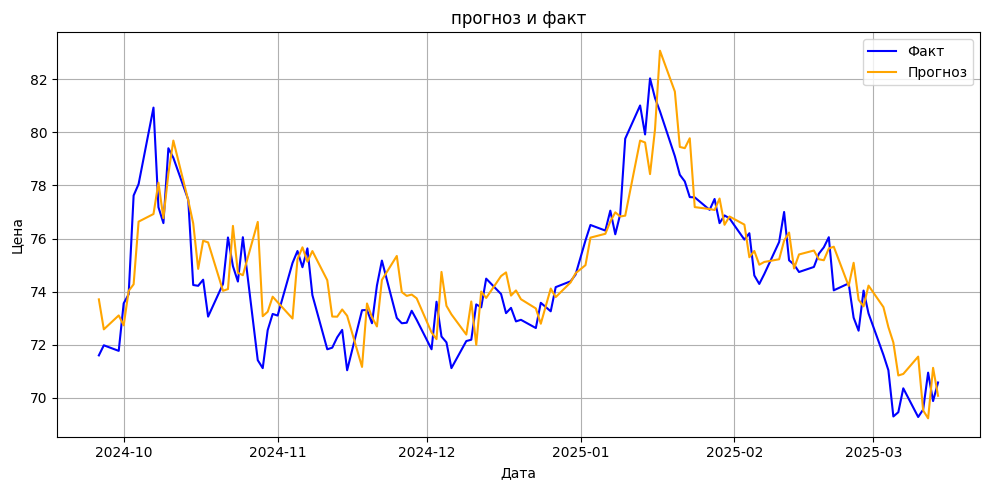

In [10]:
best_model_GradientBoostingRegressor(futures_Brent_LCOK5, 'futures_Brent_LCOK5', {'n_estimators': 297, 'learning_rate': 0.019697172771786824, 'max_depth': 5, 'subsample': 0.9105318359955741, 'min_samples_split': 10, 'min_samples_leaf': 3})

### Акции метталургических компаний

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                  Тестирование датасета: share_metal_jiangxi_copper                                                   
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 0.4214


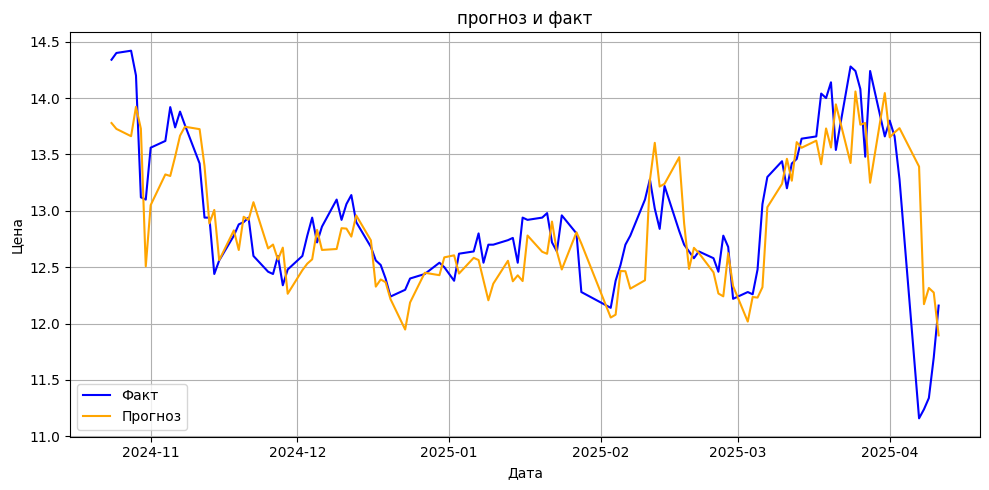

In [11]:
best_model_GradientBoostingRegressor(share_metal_jiangxi_copper, 'share_metal_jiangxi_copper', {'n_estimators': 259, 'learning_rate': 0.0394105112768372, 'max_depth': 5, 'subsample': 0.552561648631057, 'min_samples_split': 6, 'min_samples_leaf': 4})

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                   Тестирование датасета: share_metal_baoshan_iron                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 0.1979


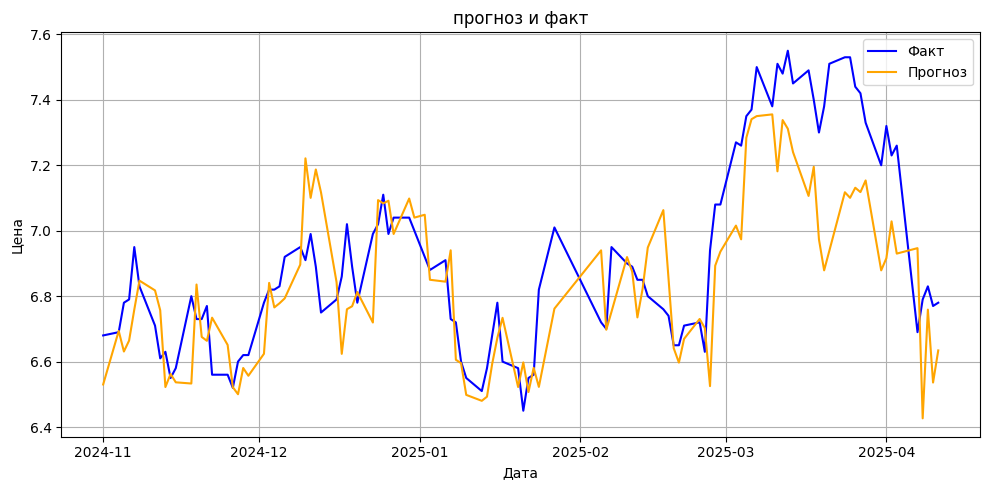

In [12]:
best_model_GradientBoostingRegressor(share_metal_baoshan_iron, 'share_metal_baoshan_iron', {'n_estimators': 156, 'learning_rate': 0.06267709307510576, 'max_depth': 4, 'subsample': 0.5035597846532046, 'min_samples_split': 6, 'min_samples_leaf': 5})

### Акции нефтедобывающих компаний

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                    Тестирование датасета: share_oil_petrochina_hk                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 0.6703


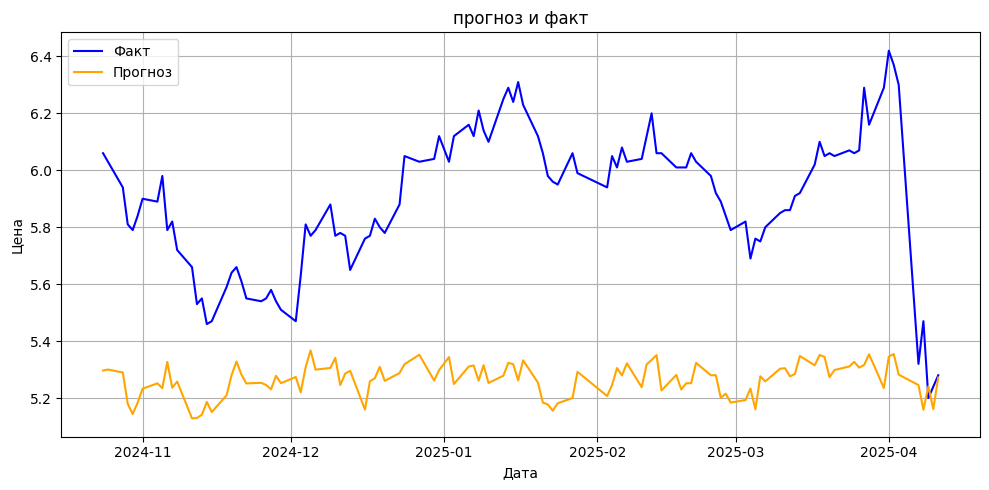

In [13]:
best_model_LGBM(share_oil_petrochina_hk, 'share_oil_petrochina_hk', {'n_estimators': 153, 'learning_rate': 0.054276399679638106, 'max_depth': 7, 'num_leaves': 136, 'min_child_samples': 22})

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                    Тестирование датасета: share_oil_equinor_oslo                                                     
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 8.0008


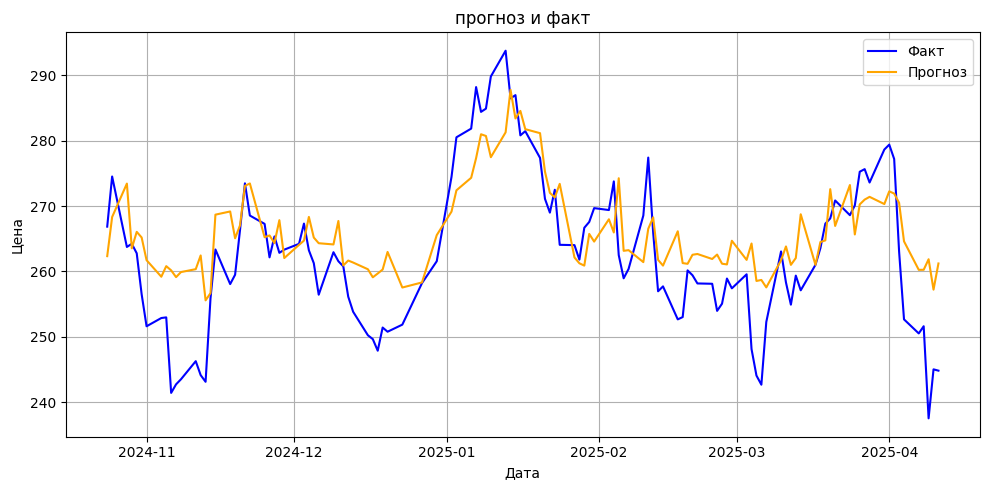

In [14]:
best_model_LGBM(share_oil_equinor_oslo, 'share_oil_equinor_oslo', {'n_estimators': 148, 'learning_rate': 0.022906413238095946, 'max_depth': 5, 'num_leaves': 73, 'min_child_samples': 22})

### Спотовы цена на драгоценные металы

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                    Тестирование датасета: spot_preciouse_metal_AG                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 4.1691


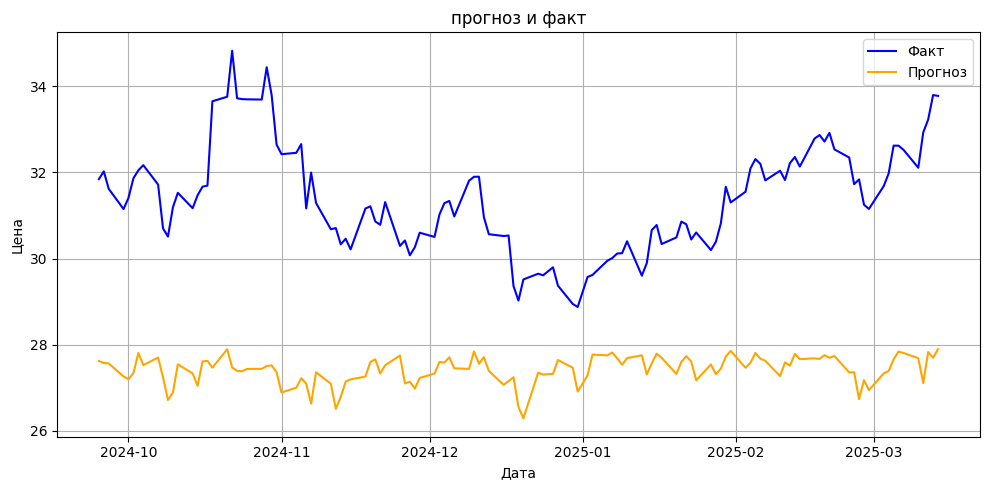

In [15]:
best_model_LGBM(spot_preciouse_metal_AG, 'spot_preciouse_metal_AG', {'n_estimators': 154, 'learning_rate': 0.04394280207031388, 'max_depth': 9, 'num_leaves': 17, 'min_child_samples': 9})

------------------------------------------------------------------------------------------------------------------------------------------------------
                                                    Тестирование датасета: spot_preciouse_metal_AU                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE на валидации: 729.2326


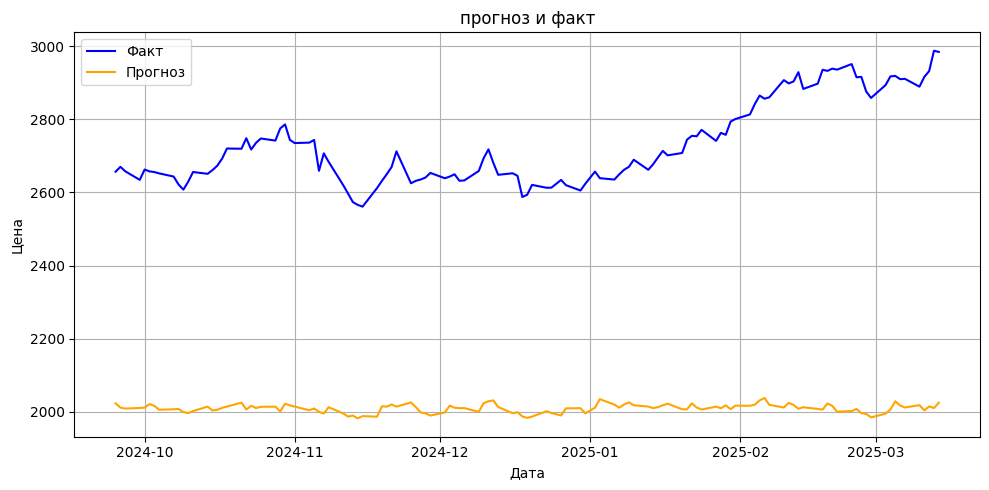

In [17]:
best_model_LGBM(spot_preciouse_metal_AU, 'spot_preciouse_metal_AU',  {'n_estimators': 154, 'learning_rate': 0.04394280207031388, 'max_depth': 9, 'num_leaves': 17, 'min_child_samples': 9})